In [1]:
import re
phone_num_pattern_obj = re.compile(r'\d{3}-\d{3}-\d{4}')
match_obj = phone_num_pattern_obj.search('My number is 415-555-4242.')
match_obj.group()

'415-555-4242'

In [3]:
phone_re = re.compile(r'(\d\d\d)-(\d\d\d-\d\d\d\d)')
mo = phone_re.search('My number is 415-555-4242.')
print(mo.group(1))  # Returns the first group of the matched text
print(mo.group(2))  # Returns the second group of the matched text
print(mo.group(0))  # Returns the full matched text
print(mo.group())  # Also returns the full matched text

415
555-4242
415-555-4242
415-555-4242


The \(and \) escape characters in the raw string passed to re.compile() will match actual parenthesis characters. In regular expressions, the following characters have special meanings:
$ () * + - . ? [\] ^ {|}

If you want to detect these characters as part of your text pattern, you need to escape them with a backslash:
\$ \(\) \* \+ \- \. \? \[\\ \] \^ \{\| \}

In [28]:
pattern = re.compile(r'Cat(erpillar|astrophe|ch|egory)')
match = pattern.findall('Catch me if you can in this major catastrophe.')
print(match)

['ch']


In [5]:
pattern = re.compile(r'\d{3}-\d{3}-\d{4}')  # This regex has no groups.
pattern.findall('Cell: 415-555-9999 Work: 212-555-0000')

['415-555-9999', '212-555-0000']

In [6]:
pattern = re.compile(r'(\d{3})-(\d{3})-(\d{4})')  # This regex has groups.
pattern.findall('Cell: 415-555-9999 Work: 212-555-0000')

[('415', '555', '9999'), ('212', '555', '0000')]

In [7]:
pattern = re.compile(r'\d{3}')
print(pattern.findall('1234'))
print(pattern.findall('123456'))

['123']
['123', '456']


In [8]:
# vowel patterns 
vowel_pattern = re.compile(r'[aeiouAEIOU]')
vowel_pattern.findall('RoboCop eats BABY FOOD.')

['o', 'o', 'o', 'e', 'a', 'A', 'O', 'O']

In [ ]:
# negative character classes
consonant_pattern = re.compile(r'[^aeiouAEIOU]')
consonant_pattern.findall('RoboCop eats BABY FOOD.')

['R', 'b', 'C', 'p', ' ', 't', 's', ' ', 'B', 'B', 'Y', ' ', 'F', 'D', '.']

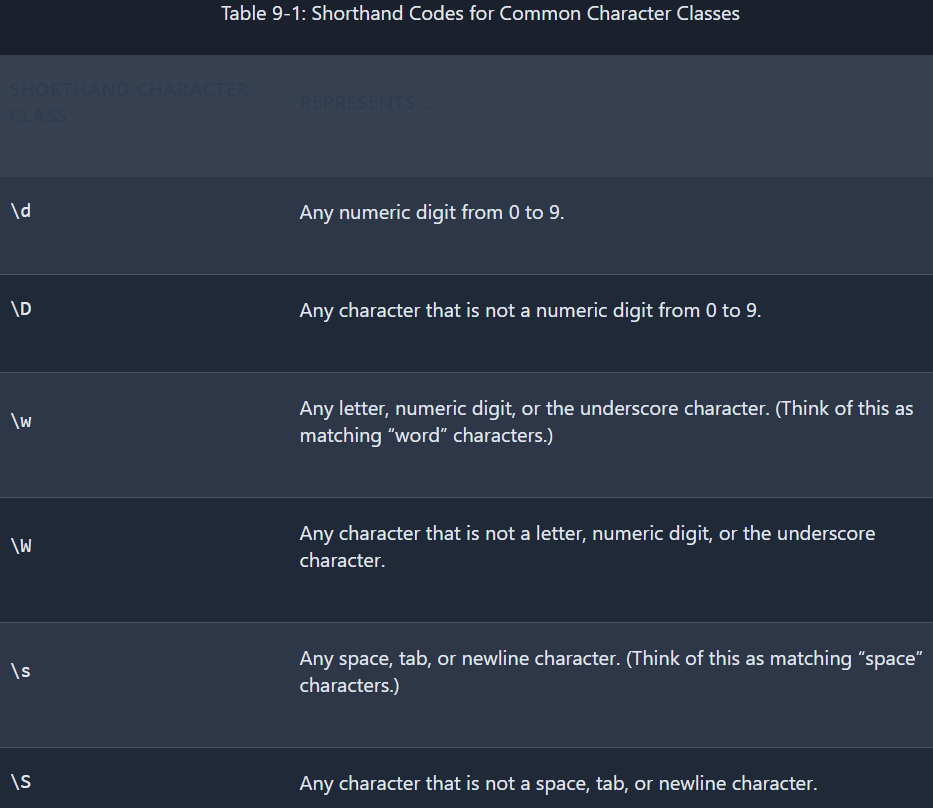

In [10]:
pattern = re.compile(r'\d+\s\w+')
pattern.findall('12 drummers, 11 pipers, 10 lords, 9 ladies, 8 maids, 7 swans, 6 geese, 5 rings, 4 birds, 3 hens, 2 doves, 1 partridge')

['12 drummers',
 '11 pipers',
 '10 lords',
 '9 ladies',
 '8 maids',
 '7 swans',
 '6 geese',
 '5 rings',
 '4 birds',
 '3 hens',
 '2 doves',
 '1 partridge']

In [11]:
# dot character
at_re = re.compile(r'.at')
at_re.findall('The cat in the hat sat on the flat mat.')

['cat', 'hat', 'sat', 'lat', 'mat']

In [ ]:
# the "?" means a character search is optional
pattern = re.compile(r'42!?')
print(pattern.search('42!'))
print(pattern.search('42'))

<re.Match object; span=(0, 3), match='42!'>
<re.Match object; span=(0, 2), match='42'>


In [15]:
pattern = re.compile(r'(\d{3}-)?\d{3}-\d{4}')
match1 = pattern.search('My number is 415-555-4242')
print(match1.group())

match2 = pattern.search('My number is 555-4242')
print(match2.group())

415-555-4242
555-4242


In [19]:
pattern = re.compile('Eggs( and spam)*')
match1 = pattern.search("Eggs")
print(match1.group())

match2=pattern.search("Eggs and spam and spam and spam")
print(match2.group())

Eggs
Eggs and spam and spam and spam


In [ ]:
# ^ can be used to check starting of a string, 
begins_with_hello = re.compile(r'^Hello')
print(begins_with_hello.search('Hello, world!'))

<re.Match object; span=(0, 5), match='Hello'>


In [23]:
# $ can be used to check for ending
ends_with_number = re.compile(r'\d+$')
print(ends_with_number.search('Your number is 42'))

<re.Match object; span=(15, 17), match='42'>


In [ ]:
# The r'^\d+$' regular expression string matches strings that both begin and end with one or more numeric characters
whole_string_is_num = re.compile(r'^\d+$')
print(whole_string_is_num.search('1234567890'))

<re.Match object; span=(0, 10), match='1234567890'>


In [ ]:
# \b is used when we want to make sure a word begins with a certain string
pattern = re.compile(r'\bcat.*?\b')
pattern.findall('The cat found a catapult catalog in the catacombs.')

In [27]:
# The \B syntax matches anything that is not a word boundary:
pattern = re.compile(r'\Bcat\B')
print(pattern.findall('certificate'))  # Match
print(pattern.findall("catastrophe"))  # No match

['cat']
[]


In [28]:
# case insensitive matching
pattern = re.compile(r'robocop', re.I)
pattern.search('RoboCop is part man, part machine, all cop.').group()

'RoboCop'

In [29]:
# substituting strings
agent_pattern = re.compile(r'Agent \w+')
agent_pattern.sub('CENSORED', 'Agent Alice contacted Agent Bob.')

'CENSORED contacted CENSORED.'

In [30]:
agent_pattern = re.compile(r'Agent (\w)\w*')
agent_pattern.sub(r'\1****', 'Agent Alice contacted Agent Bob.')

'A**** contacted B****.'

In [31]:
# Verbose multiline regular expression
pattern = re.compile(r'''(
    (\d{3}|\(\d{3}\))?  # Area code
    (\s|-|\.)?  # Separator
    \d{3}  # First three digits
    (\s|-|\.)  # Separator
    \d{4}  # Last four digits
    (\s*(ext|x|ext\.)\s*\d{2,5})?  # Extension
    )''', re.VERBOSE)

In [2]:
from humre import *
phone_regex = exactly(3, DIGIT) + '-' + exactly(3, DIGIT) + '-' + exactly(4, DIGIT)
phone_regex

'\\d{3}-\\d{3}-\\d{4}'

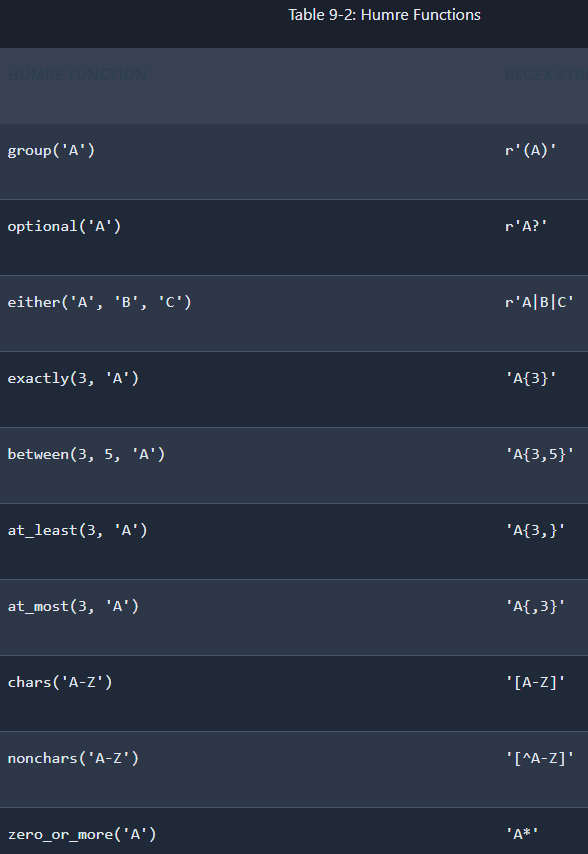
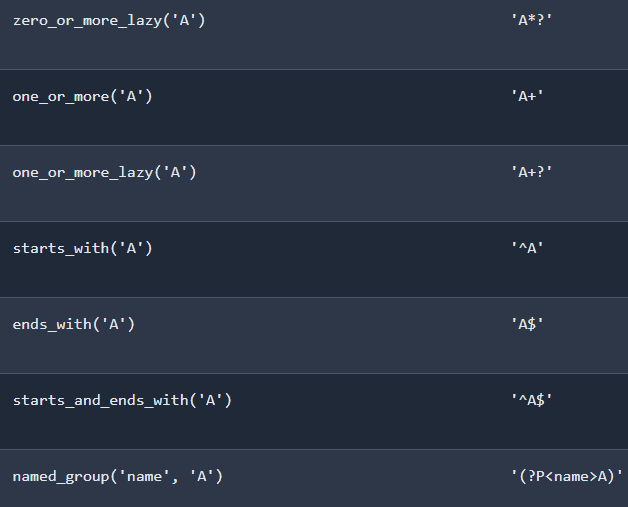
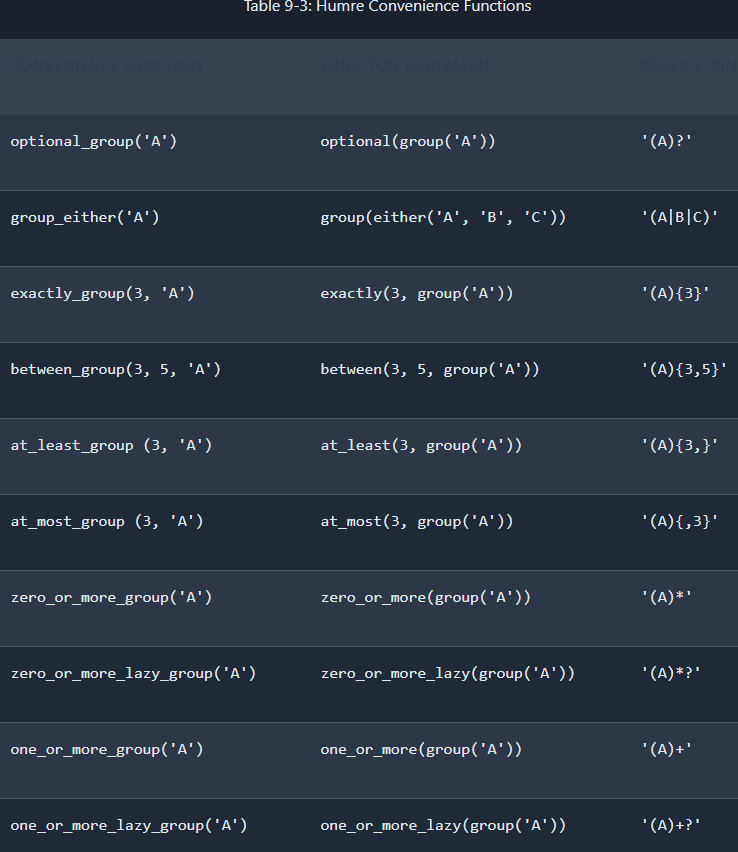
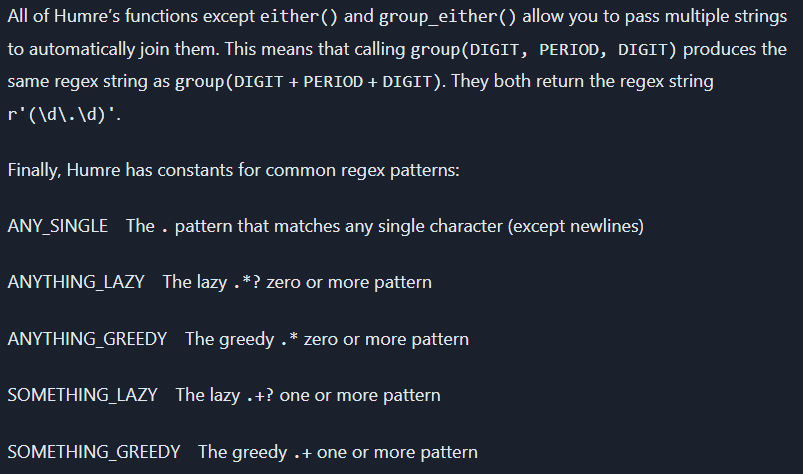

1. Warm-up: extract digits
Write a regex and use findall() to pull every number out of this string:

In [4]:
text = "I have 3 cats, 12 fish, and 107 stamps."
pattern=re.compile(r'\d+')
match=pattern.findall(text)
print(match)

['3', '12', '107']


2. Match a simple date
Write a regex that matches dates in the format MM/DD/YYYY (e.g. 04/22/2025). Test it against "The event is on 04/22/2025 and ends 12/01/2025." using findall().

In [5]:
text = "The event is on 04/22/2025 and ends 12/01/2025."
pattern=re.compile(r'\d+/\d+/\d+')
match=pattern.findall(text)
print(match)

['04/22/2025', '12/01/2025']


3. Extract the parts of a date
Modify exercise 2 to use groups so you can separately capture month, day, and year. Print each group for every match.

In [14]:
pattern=re.compile(r'(\d+)/(\d+)/(\d+)')
match=pattern.findall(text)
for i in match:
    print(f"Month: {int(i[0])}, Date: {int(i[1])}, Year: {int(i[2])}")

Month: 4, Date: 22, Year: 2025
Month: 12, Date: 1, Year: 2025


4. Hashtag finder
Write a regex to find all hashtags in a tweet-like string (a hashtag starts with # followed by one or more word characters):

In [15]:
text = "Loving the #sunset and #GoodVibes today! #2025goals"
pattern=re.compile(r'(#[a-zA-Z0-9]*)')
match=pattern.findall(text)
match

['#sunset', '#GoodVibes', '#2025goals']

5. Optional area code
Write a single regex that matches phone numbers both with and without a parenthesized area code, e.g. both (415) 555-4242 and 555-4242.

In [23]:
t1="(415) 555-4242"
t2= "555-4242"
pattern=re.compile(r'(\(\d\d\d\)\s){0,1}(\d{3}-\d{4})')
match=pattern.findall(t2)
print(match)

[('', '555-4242')]


6. Validate a username
Write a function is_valid_username(s) that returns True only if s is 4–15 characters long and contains only letters, digits, and underscores. (Hint: use ^ and $ with a quantifier range.)

In [ ]:
def is_valid_username(s):
    pattern=re.compile(r'^[a-zA-Z0-9_]{4,15}$')
    match=pattern.findall(s)
    if match:
        return True
    return False

print(is_valid_username("!!validuser!!"))   
print(is_valid_username("user_123"))        
print(is_valid_username("ab"))              
print(is_valid_username("thisusernameiswaytoolong"))  

False
True
False
False
